<div style="page-break-before: always;"></div>

# Introduction to Underwater Systems

This notebook is the opening handout for the MSc course on underwater systems (MSc Robotics and Automation of the University of Pisa, Italy). It is written so you can read it as a PDF first. If you run the notebook, the same material is there with figures, links, and a few prompts.

Underwater robots sit at the intersection of mechanics, sensing, communications, navigation, and autonomy. The constraints are not subtle: radio does not work underwater, GPS does not work underwater, pressure grows quickly with depth, and even simple tasks (like “hold position” or “send a message”) become problems.

A practical goal for this course is to develop a shared vocabulary for platforms (ROVs, AUVs, gliders, surface vehicles), sensing, and autonomy, and then use that vocabulary to reason about real missions and design choices.

## Lab overview

Before diving into the beautiful world of maritime robotics and underwater systems, a short introduction about our lab.

We are a robotics lab that works on **maritime robotics**, with a focus on **autonomy** and **AI**. Much of the work follows the same loop: design an algorithm, test it in simulation, validate on real data, and, when logistics allow, run field experiments.

The systems we work with range from small vehicles used for rapid prototyping to larger platforms used for extended missions. The details vary from project to project, but the underlying engineering questions recur: how to navigate without GPS, how to sense reliably in a difficult environment, how to plan missions under energy and communication constraints, and how to keep a human in the loop when the system matters.


### Robots and Platforms

The lab uses a mix of platforms. 
Some are designed for long missions and higher payload capacity; others are compact systems used to iterate quickly on sensing, control, and autonomy. This mix is deliberate: it is hard to develop robust autonomy if you only test in one operating regime.
The following figures show three of the robotic vehicles we routinely use for our experiments: AUV Zeno, AUV X300, and the BlueROV.

![Figure: X300/Folaga](./images/1.introduction/0.robot-x300.jpg){width=50%}

The picture above shows the X300 AUV, formerly known as Folaga AUV. This vehicle was developed in our lab! and it is today commercialised by Graaltech a company based in Genova. It is arguably the most successful underwater vehicle in Italy, and one of the most successful ones in Europe. It was the first maritime robot that did not coast a fortune! (it still costs 100K Euros with sensors) and this was one of the reasons for its commercial success. We will come back to this vehicle later in the course. 

![Figure: Zeno AUV](./images/1.introduction/0.Zeno_HR.png){width=50%}

Zeno AUV. AUV stands for Autonomous Underwater Vehicle. This robot is manufactured in Florence by a company called MDMTeam.

![Figure: BlueRov](./images/1.introduction/0.robot-bluerov.jpg){width=50%}

BlueRov is a small Remotely Operated Vehicle (ROV) manufactured by BlueRobotics. They manufacture low costs but very reliable vehicles, including a Autonomous Surface Vessel (ASV), called BlueBoat.

We are also in the process of acquiring one more AUV - the Oceanscan Light AUV (LAUV) will soon join our fleet. This is a long endurance vehicle and it will enable us to do longer and more complex missions.

### Locations

Field work in marine robotics is shaped by access: ports, test sites, regulations, weather windows, and the availability of vessels. The lab operates across different environments, from sheltered coastal areas suitable for early integration tests to offshore conditions that stress navigation, sensing, and mission execution.

In the rest of the course, when we discuss “requirements”, keep in mind that many requirements come directly from the operating context: depth, currents, visibility, legal constraints, and the practical cost of repeating an experiment.


The lab is part of the broader robotics and systems ecosystem at the University of Pisa, and it collaborates on projects where autonomy, human–robot interaction, and field validation are central.

![Figure: Our Lab and Facilities.](./images/1.introduction/dii.png){width=100%}

The picture above shows some of the facilities that we have in the lab. We have an office in La Spezia, inside the premises of the CSSN. This gives us easy access to the water and makes it possible for us to easily test in real environments.

For smaller scale water tests, we also go to "Laghetti di Campo" in Pisa. Water depth is quite shallow there though and only some experiments can be performed.

This is where we run the final demo for this course and where you will have the opportunity to test your algorithms on one of our robots!


### Some Recent and Current Projects

The following are examples of some of the projects that we have in the lab. They can give you an idea of the breadth of research that we do.

#### Human-Machine Teaming For the Maritime Environment

Underwater missions often require a human operator to remain accountable while the vehicle operates with limited communication. That pushes us toward interaction and control methods that allow **shared decision-making**: the robot can propose actions and handle low-level execution, while a human can guide intent, intervene, and manage risk.

![Figure: Human-Machine Teaming For the Maritime Environment: We study how to use and operate multiple robots with fewer operators. This requies making robots more intelligent](./images/1.introduction/0.project-hume.png)

The picture above shows a concept that for us is really important: normal maritime robotic operations are managed by lots of operators that are responsible for a small number of vehicles (normally: 5 operators per robot). We are investigating how to make it possible to reverse that and have 1 operator controlling tens of robots!


A practical challenge in real systems is integration: sensing, navigation, planning, and communications are often developed by different teams and evolve over time. One line of work in the lab is about building autonomy in a way that can be composed, tested, and replaced without rewriting the entire system.

![Figure: Concept of composable Autonomy](./images/1.introduction/0.composable.png){width=100%}

This is summarised in the picture above, where the end-to-end system is fully modular and the intelligence can be moved around the system depending on objectives and resources. Note that the system interact with operators using high-level descriptions, similarly to what chatGPT does, to help operators learn and use the systems as quickly and as easily as possible.


### Quantum-based navigation

Navigation is a bottleneck for many marine missions, especially when GPS is unavailable or unreliable (which is most of the time underwater, and increasingly relevant on the surface as well). A research direction in the lab is to improve navigation performance by combining classical sensors with next-generation sensing, and by using learning-based models where they actually help.

One important research direction that we are pursuing is using quantum sensors to improve navigation performance. These new sensors make it possible to see the world in a completely new (and weird!) way and able to overcome the limitations of traditional sensors. We are coupling quantum technology with artificial intelligence to bring about the next generation of navigation systems for maritime vehicles - as we will discuss navigation underwater is very complicated because we don't have access to the normal way (for example, there is no GPS underwater) so this is a pretty big deal :)
The picture below shows a simple schematic of how our system in built to incorporate quantum sensing and more traditional technology.

![Figure: We use quantum sensors to improve navigation performance of our robots. The picture describes the navigation stack developed at the lab to support Quantum Navigation](./images/1.introduction/0.quantum-algs.png)

Some projects are algorithmic; others are systems work where the difficult part is integration, calibration, and repeatable testing in operational conditions.
The next picture shows an example from an experiment of our quantum sensing system. The sensor (on the right in the picture) was installed on a rubber boat and used to navigate in the gulf of La Spezia. This was part of a project that we run with the Centre for Maritime Research and Experimentation (CMRE) and TNO in the Netherlands.

![Figure: Our team at sea during an experiment of Quantum Navigation](./images/1.introduction/0.quantum-exp.png){width=100%}

### Underwater acoustic source localization using a multi-robot system

Acoustics is the closest thing we have to long-range sensing and communication underwater, but it comes with multipath, time-varying propagation, and strong dependence on geometry. Multi-robot setups can improve coverage and robustness, but they also add coordination and synchronization problems.

![Figure: Resilient Sensing. Sense-Plan-Act loop: Making robots able to perceive their environment with resilience is key to improve their operational effectiveness.](./images/1.introduction/0.resilient-sensing.png){width=100%}

### Underwater acoustic source localization using a multi-robot system

This project direction is also a good example of the “full stack” nature of underwater robotics: the algorithm is only one piece. The objective in this case was how to use multiple vehicles to localise sources of sound underwater.
Vehicle motion, array geometry, clock drift, deployment logistics, and data handling can dominate performance if they are treated as afterthoughts. We will go into the details of what this all means through the course.

![Figure: Underwater acoustic source localization using a multi-robot system (Project DAMPS)](./images/1.introduction/0.project-damps.png){width=100%}

### MSc Thesis Programme: Maritime Robotics, Artificial Intelligence and Robot Autonomy

Finally, a few words on our MSc thesis programme. 
We supervise MSc theses on maritime robotics, with a strong focus on autonomy and AI. A typical thesis involves algorithm design, simulation, testing on real data, and, when possible, field work.

The main research directions include human–robot teaming and shared autonomy (interfaces and control methods that let a human and an autonomous system share decisions during a mission), multi-robot collaboration (coordination and task allocation for teams of robots), mission and path planning for long-duration operations (energy, currents, risk, uncertainty, and limited communication), polar robotics (operating in cold and remote environments, with robustness constraints), and navigation and sensor fusion topics that include magnetometers and, when relevant, quantum or next-generation sensors.

Some thesis projects are run with external partners. Recent collaborations include Atlas Elektronik (typically with about one month onsite, with travel and living expenses covered), Fincantieri WASS, the National Oceanography Centre (NOC), and CMRE (NATO Centre for Maritime Research and Experimentation).

Students can also apply for Erasmus exchanges. Current partners include Leibniz Universität Hannover, University of Zagreb, University of Girona, and Heriot-Watt University (from 2027), among others.

For details and applications, contact Prof. Andrea Munafo at [andrea.munafo@unipi.it](mailto:andrea.munafo@unipi.it).


------

## What's in this introduction?

This introduction does four things. It starts from motivation: why we use robots to explore, monitor, and inspect the sea. It then sketches what “underwater systems” means in practice, not as a definition but as a set of constraints that are important to shape design. Finally, it maps those constraints to the main topics of the course, so that later material has a clear place to attach.


## Motivations

Marine robotics exists because the ocean is hard to access and expensive to observe. If you need repeated measurements over large areas, or you need to inspect structures and assets without putting divers at risk, you quickly end up with robotic systems.

A second motivation is scientific: many ocean processes are dynamic and spatially distributed. You rarely get what you need from a single stationary sensor. Robots let you move, sample, and adapt a mission based on what you are observing.


<!-- ### Science Questions -->
 
 
<!--table>
    <tr>
    <td>
    <figure>
    <video controls src="./videos/Using-AI-to-Explore-Oceans.mp4" width="600" height="400" frameborder="0"></video> 
    <figcaption>MIT 2.680 course - using AI to explore the ocean.</figcaption>        
    </figure>    
    </td>    
    </tr>
</table-->  


<!--table>
    <tr>
    <td>
    <iframe width="600" height="400" src="./videos/Using AI to Explore Oceans.mp4" frameborder="0" allowfullscreen></iframe>   
    </td>    
    </tr>
</table-->  

### Climate Change

Climate change, as we've seen in recent news and scientific reports, is a global phenomenon with far-reaching impacts on both terrestrial and aquatic ecosystems.

#### Global Temperature Rise
Climate change is fundamentally driven by the increase in global average temperatures year after year. This rise in temperature is not a uniform process but varies across different regions and timescales.

![Figure: Change in annual average global temperature over more than 100 years](./images/1.introduction/1.avg_temp_change_chart-nc.png.webp){width=90%}


The plot above shows global average temperature relative to the pre-industrial average (1850–1900), reproduced from [BBC | Global warming set to break key 1.5C limit for first time](https://www.bbc.com/news/science-environment-65602293).

Zero on the vertical axis is a reference baseline (a multi-decade average leading up to the 20th century). Each bar shows a single year relative to that baseline: red bars are warmer-than-baseline years, blue bars are cooler-than-baseline years.

A rise of about 1.1 °C over the last century sounds small if you think of day-to-day weather, but it corresponds to an enormous increase in stored energy in the Earth system. That energy shows up in multiple ways: changes in the frequency and intensity of extreme events, melting land ice and polar ice, sea level rise, and shifts in ocean temperature that affect ecosystems.


The consequences of this temperature rise are diverse, including:

- Extreme Weather Events: Such as droughts and floods.
- Melting Glaciers and Polar Ice Caps: Leading to rising sea levels.
- Impact on Marine Life: Changes in ocean temperatures and chemistry affect marine ecosystems.

#### The Role of Human Activities

Human activities, particularly the burning of fossil fuels like coal, oil, and gas, have been central to the rise in global temperatures.

![Figure: Global primary energy consumption by source](./images/1.introduction/1.Global-energy-substitution.png){width=90%}


Burning fossil fuels releases greenhouse gases (GHGs) like carbon dioxide (CO2), methane (CH4), and others into the atmosphere. These gases trap heat from the sun, leading to a warming effect known as the greenhouse effect.

![Figure: Co2 levels over the last 800k years.](./images/1.introduction/1.Co2-levels-800k.jpg){width=90%}

![Figure: CO2 levels](./images/1.introduction/1.cO2.png)

Ice cores provide a long record of atmospheric composition because they trap small air bubbles as snow compacts into ice. Measurements from these bubbles show that, for roughly the last 800,000 years up to the 20th century, atmospheric CO₂ stayed within about 170–300 ppm (parts per million). Against that background, the modern rise to above 400 ppm within roughly two centuries is unusually fast.

For additional context and data sources, see [this discussion](https://rateofchange.substack.com/p/the-rate-of-change-july-15-2019) and [the BAS overview](https://www.bas.ac.uk/data/our-data/publication/ice-cores-and-climate-change/).


The levels of CO2 in the atmosphere have been remarkably stable over millennia but have shown an unprecedented rise in the last century. Understanding this requires examining historical data:

- Ice Core Data: Scientists analyze ice cores to measure historical CO2 levels. These cores contain air bubbles that serve as time capsules, preserving atmospheric samples from the past.
- Trends Observed: Historical data shows a dramatic increase in CO2 levels, especially in recent decades. This rise is directly linked to human activities, particularly the burning of fossil fuels.
- Acceleration of CO2 Increase: The rate of increase in CO2 levels is not constant but accelerating. This acceleration implies a continually increasing rate of heat trapping in the atmosphere.

See also [NASA | Ice Cores](https://climate.nasa.gov/news/2616/core-questions-an-introduction-to-ice-cores/)

#### Global Temperature Anomalies

Lobal warming is not uniform across the Earth. Variations exist due to factors like geographical location, land-sea distribution, and atmospheric circulation patterns.

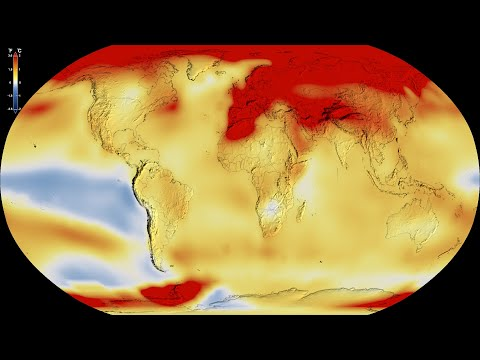

In [2]:
from IPython.display import YouTubeVideo

YouTubeVideo('LwRTw_7NNJs', width=800, height=600)

#### Oceans Are Absorbing Almost All of the Globe’s Excess Heat

- More than 90 percent of the excess heat retained by the Earth as a result of increased greenhouse gases has been absorbed by the oceans.
- Ocean temperatures have been consistently rising for at least three decades.

Interested readers are referred to this NYTimes article: [Oceans Are Absorbing Almost All of the Globe’s Excess Heat](https://www.nytimes.com/interactive/2016/09/12/science/earth/ocean-warming-climate-change.html)

**Marine Robotics and Underwater Systems are central to this problem**. 

The Figure below shows average temperature from each decade compared with the 20th-century average.

![Figure: Average temperature from each decade compared with the 20th-century average](./images/1.introduction/1.ocean-warming.webp){width=90%}

### Celebrating Marie Tharp

- American geologist and oceanographic cartographer who helped prove the theories of continental drift. 
- She co-published the first world map of the ocean floors. 
- On Nov 21, 1998, the Library of Congress named Tharp one of the greatest cartographers of the 20th century.


<table>    
    <tr>
    <td style="width=100px">
    <figure>
    <img src="./images/1.introduction/marie-tharp.png" alt="marie-tharp" style="width: 450px;"/> 
    </figure>  
    </td>           
    </tr>
</table>  


<table><tr>
<td> <img src="./images/1.introduction/11.the-world-ocedan-floor-tharp.jpeg" alt="World ocean floor" style="width: 700px;"/>
</tr></table>  


[Manuscript painting of Heezen-Tharp "World ocean floor" map by Berann (~1955)](https://www.loc.gov/item/2010586277/)

## Finding the Endurance

The wreck of Sir Ernest Shackleton’s ship 'Endurance' has been found off the coast of Antarctica more than a century after it sank.

_Historian Dan Snow, who is a member of the Endurance22 expedition team, said the discovery was 'like a miracle' and the ship is 'almost perfectly preserved'_

<table><tr>
<td> <img src="./images/1.introduction/9.shackelton-expedition.webp" alt="endurace" style="width: 350px;"/>
<td> <img src="./images/1.introduction/8.endurance-vessel.webp" alt="black-box" style="width: 350px;"/> </td>
</tr></table>  

<table><tr>
<td> <img src="./images/1.introduction/7.endurance.webp" alt="black-box" style="width: 350px;"/> </td> 
<td> <img src="./images/1.introduction/10.auv-endurance.webp" alt="black-box" style="width: 350px;"/> </td> 
</table>

see [this](https://www.bbc.com/news/science-environment-60662541) for more!

## Blackbox recovery

A useful way to frame underwater systems is to look at missions that are not “robotics research”, but still require robotics-grade technology. Aircraft blackbox recovery is one of those missions: it is time-critical, high-stakes, and happens in an environment where sensing and access are constrained.

The case study below is used here to motivate three course themes: (i) the operational cost of the ocean, (ii) the role of sensing and localisation when you do not control the environment, and (iii) why autonomy becomes valuable when human-in-the-loop bandwidth is limited.

Air France 447 crash from Rio to Paris, June 1st, 2009


<table>
    <tr>
    <td> 
    <img src="./images/1.introduction/3.bbc-flight.png" alt="flight-bbc" style="width: 650px;"/>
    </td>
</table>  

<table>
    <tr>
<td> <img src="./images/1.introduction/1.black-box.jpeg" alt="black-box" style="width: 250px;"/> </td>
<td> <img src="./images/1.introduction/2.image-website-of-Frances--007.webp" alt="black-box" style="width: 250px;"/> 
    </td> 
    </tr>
</table>

**Countries involved**

Large-scale maritime recovery operations quickly become multi-national and multi-stakeholder. Even in a single accident, relevant parties can include the country of origin, the destination country, the state responsible for the airspace where the accident happened, the airline, engine manufacturers, insurers, and the countries of citizenship of passengers.


**Recovery**

The recovery effort involved assets from multiple countries. Public summaries list 13 aircraft and 2 helicopters (Brazil, France, USA, Spain), 8 ships (Brazil, France, USA), two 6000 m manned submersibles (including *Nautile*), a French nuclear submarine, three AUVs, and one ROV. The searched area is often reported as on the order of 1 million km²; for scale, the contiguous United States is about 8,080,464 km². The cost is commonly cited around 30 M€ (2009), and the recovery was completed about two years after the crash.

The numbers matter less than the message: once you move to deep water and large areas, search becomes a sensing and systems problem, not just an “add more people” problem.


![Figure: Nautile](./images/1.introduction/4.nautile.jpeg){width=50%}

![Figure: Abyss](./images/1.introduction/5.abyss.jpeg){width=50%}

![Figure: ROV Remora](./images/1.introduction/6.remora.png){width=50%}


## Installation of Procution Well Jumper

Industrial underwater work is another anchor point for this course. Offshore installation tasks force you to think about manipulation, perception, control, and safety under real constraints: limited visibility, strong currents, heavy tooling, and the need to verify what happened.

When we later discuss ROVs, manipulators, and autonomy, keep this type of task in mind. A lot of engineering effort goes into making operations repeatable and auditable, not “clever”.

## Operating ROVs

Remotely operated vehicles (ROVs) let us work underwater without putting a person in the water. An operator is typically on a surface vessel and controls the vehicle through a tether. The tether carries power and communication, so ROV endurance is usually limited by logistics rather than battery energy.

Control is often described as “video game-like” because many systems use joysticks and live video. That similarity is misleading in one important way: the environment pushes back. The vehicle moves in currents, the camera view can be poor, and the tether influences vehicle motion. Manipulation adds another layer because forces at the end-effector couple to the vehicle body.

Most ROVs carry at least cameras and lights, and many carry tools such as manipulators, cutting arms, samplers, and sensors (turbidity, temperature, etc.). ROVs were developed largely for industrial inspection and intervention (pipelines, offshore platforms), and they are now widely used in scientific work and, increasingly, for public-facing exploration through live broadcast.

<table><tr>
<td style="width:650px">
    <figure>
    <img src="./images/1.introduction/12.rov-whoi-control-room.jpeg" alt="WHOI Engineer Jared Schwartz pilots the remotely operated vehicle, Saab Seaeye Falcon to investigate an unrecovered mooring anchor. (Photo by Daniel Hentz, Woods Hole Oceanographic Institution)" style="width: 650px;"/>
    <figcaption>WHOI Engineer Jared Schwartz pilots the remotely operated vehicle, Saab Seaeye Falcon to investigate an unrecovered mooring anchor. (Photo by Daniel Hentz, Woods Hole Oceanographic Institution). Ref.  https://www.whoi.edu/news-insights/content/flight-of-the-underwater-falcon/</figcaption>
    </figure>
</tr></table>  

<table><tr>
<td> <img src="./images/1.introduction/13.rov-control-full-view.png" alt="13.rov-control-full-view" style="width: 350px;"/> </td>
<td> <img src="./images/1.introduction/14.rov-control.png" alt="black-box" style="width: 350px;"/> </td> 
</table>

**Controlling ROVs: the old approach**

In early ROV operations, the offshore operator directly drove the vehicle and directly commanded the manipulator motors (often with a limited number of joints). That created predictable coordination issues: manipulator motion can disturb vehicle attitude, and stabilising the combined system is not trivial. Teams often relied on voice coordination between the pilot and the manipulator operator, plus visual feedback from cameras and observers.

This is a useful baseline because it shows what autonomy and better interfaces are trying to improve: reduce operator workload, reduce coordination overhead, and make complex tasks less brittle.


**Controlling ROVs today**

Modern ROV systems are moving toward better stabilization, higher-quality sensing, and more structured operator interfaces. On the autonomy side, the trend is not “replace the operator”; it is to automate the parts that are repetitive or time-critical (station keeping, camera/arm coordination, collision avoidance) while keeping the human responsible for intent and safety.

### Working with ROVs

- 13 people / 24h
    - 8 Pilot/Technicians (4h shift)
    - 4 Supervisors (4h shift)
    - 1 Superintendent (on call)

- How long onboard?
    - 4 to 6 weeks
    - ROV crews work 6h 7/7

<table><tr>
<td style="width:650px">
    <figure>
    <img src="./images/1.introduction/15.ROV-Jason-dark-2048x1152.jpeg" alt="ROV Jason helps recover two other underwater vehicles. (Photo by Woods Hole Oceanographic Institution)" style="width: 650px;"/>
    <figcaption>Photo by Woods Hole Oceanographic Institution. 
        Ref. https://www.whoi.edu/press-room/news-release/whois-rov-jason-assists-with-the-successful-recovery-of-two-other-underwater-vehicles/</figcaption>
    </figure>
</tr></table>  

_Ocean Exploration Trust’s ROV Hercules and Argus were stranded on the seafloor last week, but were recovered thanks to cooperation from several ocean science and exploration institutions
Woods Hole, MA — On Thursday, September 2, 2021 the remotely operated vehicle (ROV) Jason succeeded in helping recover two other underwater vehicles, ROV Hercules and Argus, that were stranded on the seafloor off the coast of British Columbia last week when their tether to the surface broke. The operation came about as a result of close collaboration and mutual aid that are a hallmark of the ocean science and exploration community and the maritime community as a whole._


## Renewable energy

Underwater systems are not only research platforms. 
They are part of large economic and societal pipelines. 
Two recurring drivers are infrastructure that needs power and communication (often via cables), and applications where work must be done continuously and at scale.

One example is fisheries and aquaculture, where monitoring, inspection, and intervention increasingly rely on marine sensing and automation.

<table><tr>
<td style="width:400px">
    <figure>
    <img src="./images/1.introduction/16.fisheries.png" alt="Fisheries" style="width: 400px;"/>
    <figcaption>NTNU AMOS - Centre for Autonomous Marine Operations and Systems</figcaption>
    </figure>
</tr></table> 

At a higher level, motivations are usually a blend of food production, health and environmental monitoring, security, and safety. Different applications weigh these differently, but they all push the same core technologies: robust sensing, reliable navigation, and systems that remain controllable when communication is limited.

## Marine Autonomy Trends

(Adapted from [here](https://oceanai.mit.edu/2.680/pmwiki/pmwiki.php?n=Site.Lectures)) 

<figure>
  <img src="./images/1.introduction/17.autonomy-trends-11.png" alt="Autonomy Trends" style="width: 550px;"/>
</figure>

<figure>
  <img src="./images/1.introduction/17.autonomy-trends-21.png" alt="Autonomy Trends" style="width: 550px;"/>
</figure>

### Early commercial marine vehicles

Before “marine autonomy” became a familiar term, many commercial systems were built around simple mission execution: follow a preplanned route, record data, and return. The hardware was already sophisticated, but much of the mission logic was constrained by what could be certified, supported, and operated repeatably.

This historical context is important because it explains why interfaces, protocols, and modular autonomy became central topics later on.

At the turn of the century, there weren't many commercial marine vehicles for sale

<figure>
    <img src="./images/1.introduction/18.remus-and-bluefin.png" alt="remus and bluefin" style="width: 550px;"/>
</figure>

<figure>
    <img src="./images/1.introduction/19.hugin.png" alt="hugin" style="width: 550px;"/>
</figure>

## Early Autonomy

<figure>
    <img src="./images/1.introduction/20.payload-autonomy.png" alt="hugin" style="width: 550px;"/>
</figure>


- Researcher/Scientists were not content to be limited to the vehicle manufacturer’s autonomy system.
- How can they run the autonomy system from the payload computer, i.e., Payload Autonomy

- **Do you see limitations or concerns with this?**

_Autonomy can be complex, sometime is data driven, might be not deterministic and might increase the risk of losing a vehicle. Losing an AUV might set a research group back many years._


## Marine Autonomy Trends

A simple way to describe the last two decades is a shift from scripted missions toward adaptive and collaborative systems.

In a scripted mission, most of the trajectory is fixed before launch. The robot still needs navigation, but the mission logic does not change much during execution.

In adaptive or collaborative autonomy, the trajectory depends on what the robot senses and, in multi-vehicle settings, on what other vehicles are doing. The robot needs not only self-localization, but also the ability to reason about other agents and to react under uncertainty.

Think of the two examples below:

<table>
    <tr>
    <td> <img src="./images/1.introduction/21.waypoints.png" alt="waypoints" style="height: 250px;"/>
    <td> <img src="./images/1.introduction/22.adaptive-autonomy.png" alt="adaptive/collaborative" style="height: 250px;"/> </td>
    </tr>
</table>


### Scripted Missions

Twenty years ago, “marine autonomy” was not a common term. 
A typical workflow was straightforward: the robot followed a sequence of waypoints, it was recovered, and scientists offloaded data for analysis. Navigation, control, and mission software were mostly delivered as an integrated package by the vehicle manufacturer.

That model has strengths. It is predictable and supportable, and it is often the right choice when operations must be repeatable.

<table>
    <tr>
    <td> <img src="./images/1.introduction/21.waypoints.png" alt="waypoints" style="height: 250px;"/>    
    </tr>
</table>  

Think about two advantages and two limitations of this approach. Try to phrase them as engineering constraints (not simply as “it’s old”).


### Adaptive autonomy

A decade later, sensor data was no longer treated as something you only look at after recovery. Vehicles started processing data on board and adjusting the mission during execution. Once missions become unscripted and dynamic, the design space grows quickly: what should trigger replanning, how safe is a deviation, what data is worth transmitting, and what happens when the vehicle is uncertain about its own state?

This shift also changed the ecosystem. Manufacturers tended to support a subset of missions aligned with core users, and many platforms opened payload interfaces so third parties (industry, academic labs, defense labs) could deploy their own autonomy stacks.

The next two pictures show this new approach:

<table>
    <tr>
    <td> <img src="./images/1.introduction/23.adaptive-complexity.png" alt="waypoints" style="height: 350px;"/>
        <td></td>
        <td></td>
    <td> <img src="./images/1.introduction/22.adaptive-autonomy-reacquire.png" alt="23.human-machine" style="height: 350px;"/> </td>
    </tr>
</table>  



### Autonomy Trends

After more than a decade of innovation in payload software, there are now many mature options for specialised autonomy, sensing, navigation, and communications. The practical consequence is that a single mission may involve software components developed by different teams or vendors.

The figure below shows - MOOS-IvP: Increased level of adoption for [MOOS-IvP](https://oceanai.mit.edu/2.680/pmwiki/pmwiki.php?n=Site.Lectures) 
<figure>
<img src="./images/1.introduction/17.autonomy-trends-32.png" alt="Autonomy Trends" style="width: 750px;"/>
</figure> 

When you can combine best-in-class components, the payoff for end users is obvious. The hard part is integration: you need protocols, message definitions, timing assumptions, and safety rules that let “systems of systems” behave as one system.


### A tangible example

And a blog post on the [World's first autonomous ferry](https://blog.geogarage.com/2018/12/rolls-royce-demonstrates-fully.html)

<figure>
<img src="./images/1.introduction/17.autonomy-trends-31.png" alt="Autonomy Trends" style="width: 550px;"/>
</figure> 

### Autonomy Trends

- After more than a decade of software innovation in the payload, there are now many good options for specialized autonomy, sensing, navigation and communications
- Many of these software solutions come from different developers/vendors.

<figure>
<img src="./images/1.introduction/17.autonomy-trends-32.png" alt="Autonomy Trends" style="width: 750px;"/>
</figure> 

- Great benefits for end-users when best-of-practice solutions can be combined
- Key challenge: how to design system protocols/messages to develop systems of autonomy systems


<table>
    <tr>
    <td> <img src="./images/1.introduction/24.human-machine.png" alt="23.human-machine" style="height: 350px;"/> </td>
    </tr>
</table>  

## Autonomous Vehicles

In this course we will talk about a few platform families and what they are good at: ROVs (tethered intervention and inspection), AUVs (untethered missions with onboard autonomy), gliders (very long endurance with low-speed sampling), and uncrewed surface vehicles (communications relay, sensing, and as a partner to underwater vehicles).


## Next challenges

The applications in marine robotics sit at the intersection of **science**, **industry**, and **defense**. The overlap is not only about “who pays”; it changes what the system must do well. A climate survey vehicle can accept missed communications for hours. A harbour inspection platform has to work on a schedule and near people. A search-and-rescue mission pushes for speed, reliability, and clear operator control. In practice, the same core technologies get reused across these domains, but the constraints shift.

<table>
  <tr>
    <td>
      <figure>
        <img src="./images/1.introduction/27.roles-for-robots.png" alt="Science–Industry–Defense application space" style="width: 650px;"/>
        <figcaption>Marine robotics applications span science, industry, and defense, with shared technical bottlenecks.</figcaption>
      </figure>
    </td>
  </tr>
</table>

Across all three domains, the next set of challenges is mainly about making systems **work reliably outside demos**:

- **Navigation without infrastructure.** Underwater, GPS is unavailable and acoustic positioning is not always available or affordable. Long missions force you to combine inertial sensing, terrain or map cues, acoustics when present, and careful uncertainty management.

- **Limited communication and operator bandwidth.** Autonomy is not a luxury feature; it compensates for low-rate, intermittent links. The hard part is designing behaviours that are safe when the vehicle is uncertain, and interfaces that let a human intervene with minimal context.

- **Energy, endurance, and payload trade-offs.** Batteries, propulsion, sensors, compute, and buoyancy compete for the same mass and volume budget. “More sensing” is rarely free; it changes endurance and logistics.

- **Verification, safety, and accountability.** The closer you get to ports, infrastructure, or time-critical missions, the more you need clear failure modes, logging, and predictable behaviour. Autonomy that cannot be explained or tested becomes difficult to deploy.

- **Integration at scale.** Modern missions often combine components from different vendors and teams (vehicle, payload, navigation stack, mission planner). This makes interfaces, timing assumptions, and reproducible data pipelines as important as any single algorithm.

These challenges set the agenda for the rest of the course: we will keep coming back to navigation, sensing, communication constraints, and the practical design choices that follow.



See <a href='00_Syllabus.ipynb' target='_blank' style='font-size: 16px;'>00_Syllabus.ipynb</a></li> for more details on the course structure.